### Import

In [1]:
# Bibliothèques principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output, Image as IPImage, display
import warnings
import os
from pathlib import Path
warnings.filterwarnings('ignore')
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# TensorFlow et Keras
import tensorflow as tf
import keras
#from tensorflow import keras
from keras import layers, models, optimizers, callbacks
from keras.applications import MobileNetV2


# Configuration GPU
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU(s) détecté(s): {len(gpus)} - Croissance mémoire activée")
    else:
        print("⚠️  Aucun GPU détecté - Utilisation du CPU (entraînement sera lent)")
except Exception as e:
    print(f"Configuration GPU: {e}")

# Configuration graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Reproductibilité
tf.random.set_seed(42)
np.random.seed(42)

print(f"\n📦 Versions des bibliothèques :")
print(f"  - TensorFlow : {tf.__version__}")
print(f"  - Keras      : {keras.__version__}")
print(f"  - NumPy      : {np.__version__}")

print(f"\n🚀 Prêt pour le fine-tuning en computer vision !")

I0000 00:00:1776506371.960495    4954 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776506372.957382    4954 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776506375.385824    4954 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


⚠️  Aucun GPU détecté - Utilisation du CPU (entraînement sera lent)

📦 Versions des bibliothèques :
  - TensorFlow : 2.21.0
  - Keras      : 3.13.2
  - NumPy      : 1.26.4

🚀 Prêt pour le fine-tuning en computer vision !


W0000 00:00:1776506376.696996    4954 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


### Chargement du modèle

In [41]:
print("📥 Chargement du modèle MobileNetV2 avec Keras...")
print("   (Cela peut prendre quelques secondes la première fois)\n")

# Charger MobileNetV2 pré-entraîné sans le classifier (include_top=False)
# On va ajouter notre propre classifier pour les fleurs
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,  # Exclure la couche de classification ImageNet
    weights='imagenet',  # Charger les poids pré-entraînés sur ImageNet
    pooling='avg'  # Global Average Pooling à la fin
)

print("✅ Modèle MobileNetV2 chargé !\n")

# Afficher la structure du modèle
print("📋 Structure du modèle MobileNetV2 :")
print(f"  - Architecture   : MobileNetV2")
print(f"  - Input shape    : (224, 224, 3)")
print(f"  - Poids          : ImageNet (1000 classes)")
print(f"  - Output shape   : {base_model.output_shape}")
print(f"  - Nombre de couches : {len(base_model.layers)}")

# Compter les paramètres
total_params = base_model.count_params()
print(f"\n  - Nombre total de paramètres : {total_params:,}")
print(f"  - Taille en mémoire (approx.) : {total_params * 4 / (1024**2):.1f} MB")

print("\n💡 Ce modèle a déjà été entraîné sur 1.4 million d'images !")

📥 Chargement du modèle MobileNetV2 avec Keras...
   (Cela peut prendre quelques secondes la première fois)

✅ Modèle MobileNetV2 chargé !

📋 Structure du modèle MobileNetV2 :
  - Architecture   : MobileNetV2
  - Input shape    : (224, 224, 3)
  - Poids          : ImageNet (1000 classes)
  - Output shape   : (None, 1280)
  - Nombre de couches : 155

  - Nombre total de paramètres : 2,257,984
  - Taille en mémoire (approx.) : 8.6 MB

💡 Ce modèle a déjà été entraîné sur 1.4 million d'images !


### Chargement du dataset

In [3]:
print (os.listdir("images_resized"))

df = pd.read_csv("images_resized/train_labels.csv")
df_val = pd.read_csv("images_resized/val_labels.csv")

categorie_mapping = {
    "Personnage": 0,
    "Action": 1,
    "Objet": 2,
    "Lieu":3
}

encre_mapping = {
    "Ambre": 0,
    "Améthyste": 1,
    "Émeraude": 2,
    "Rubis": 3,
    "Saphir": 4,
    "Acier": 5
}

rarete_mapping = {
    "C": 0,
    "U": 1,
    "R": 2,
    "SR": 3,
    "L": 4
}

df["Catégorie"] = df["Catégorie"].map(categorie_mapping)
df["Encre"] = df["Encre"].map(encre_mapping)
df["Rareté"] = df["Rareté"].map(rarete_mapping)

df_val["Catégorie"] = df_val["Catégorie"].map(categorie_mapping)
df_val["Encre"] = df_val["Encre"].map(encre_mapping)
df_val["Rareté"] = df_val["Rareté"].map(rarete_mapping)

print(df[["Catégorie","Encre","Rareté","Encrable"]][11:30])


IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def load_image(filename, label_type, label_couleur, label_rarete, label_encrable):
    img = tf.io.read_file("images_resized/train/" + filename)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)

    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)

    labels = {
        "type": label_type,
        "couleur": label_couleur,
        "rarete": label_rarete,
        "encrable": label_encrable
    }

    return img, labels

def load_image_val(filename, label_type, label_couleur, label_rarete, label_encrable):
    img = tf.io.read_file("images_resized/val/" + filename)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)

    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)

    labels = {
        "type": label_type,
        "couleur": label_couleur,
        "rarete": label_rarete,
        "encrable": label_encrable
    }

    return img, labels

train_ds = tf.data.Dataset.from_tensor_slices((
    df["New_File_name"],
    df["Catégorie"],
    df["Encre"],
    df["Rareté"],
    df["Encrable"]
)).map(load_image).cache().shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((
    df_val["New_File_name"],
    df_val["Catégorie"],
    df_val["Encre"],
    df_val["Rareté"],
    df_val["Encrable"]
)).map(load_image_val).cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(train_ds)
print(val_ds)
for x, y in train_ds.take(1):
    print("Image shape:", x.shape)
    print("Labels:", y)



['val_labels.csv', 'train', 'train_labels.csv', 'test', 'val', 'test_labels.csv']
    Catégorie  Encre  Rareté  Encrable
11          0      0       2         1
12          0      0       0         1
13          0      0       0         1
14          0      0       4         1
15          0      0       0         1
16          0      0       4         1
17          0      0       0         1
18          0      0       3         1
19          1      0       0         1
20          1      0       0         1
21          1      0       0         1
22          1      0       2         0
23          1      0       2         0
24          2      0       2         0
25          0      1       1         1
26          0      1       2         0
27          0      1       2         1
28          0      1       0         1
29          0      1       1         1
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), {'type': TensorSpec(shape=(None,), dty

W0000 00:00:1776078426.496252   38245 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


## Chargement et compilation du modèle

In [42]:
print("🧊 Construction du modèle Feature Extraction (OPTIMISÉ)...\n")

# Geler le modèle de base
base_model.trainable = False

# Architecture OPTIMALE pour ce dataset
inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)

# Classifier avec régularisation modérée
x = layers.Dropout(0.3)(x)  # Dropout modéré
x = layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(x)
x = layers.Dropout(0.3)(x)

# sorties
type_output = tf.keras.layers.Dense(4, activation="softmax", name="type")(x)
couleur_output = tf.keras.layers.Dense(6, activation="softmax", name="couleur")(x)
rarete_output = tf.keras.layers.Dense(5, activation="softmax", name="rarete")(x)
encrable_output = tf.keras.layers.Dense(1, activation='sigmoid', name='encrable')(x)

model_frozen = keras.Model(
    inputs,
    outputs=[type_output, couleur_output, rarete_output, encrable_output],
    name='MobileNetV2_Frozen')

# Compiler avec LR optimal
model_frozen.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),  # LR standard
    loss={
        'type': 'sparse_categorical_crossentropy',
        'couleur': 'sparse_categorical_crossentropy',
        'rarete': 'sparse_categorical_crossentropy',
        'encrable': 'binary_crossentropy'
    },
    loss_weights={
        "type": 1.0,
        "couleur": 1.0,
        "rarete": 2.0,   # boost rareté
        "encrable": 0.5
    },
    metrics={
        'type':['accuracy', keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top2_type_accuracy')],
        'couleur': ['accuracy', keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top2_couleur_accuracy')],
        'rarete': ['accuracy', keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top2_rarete_accuracy')],
        'encrable': ['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
    }
)

print("✅ Modèle compilé !\n")

print("📊 Architecture :")
print("  Input(224,224,3) → MobileNetV2 → Dropout(0.3) → Dense(256,relu) → Dropout(0.3) → Dense(4,softmax), Dense(6,softmax), Dense(5,softmax),Dense(1,sigmoid)")

trainable = sum([tf.size(w).numpy() for w in model_frozen.trainable_weights])
non_trainable = sum([tf.size(w).numpy() for w in model_frozen.non_trainable_weights])
print(f"\n  - Paramètres entraînables    : {trainable:,}")
print(f"  - Paramètres non-entraînables: {non_trainable:,}")
print(f"  - Total                      : {trainable + non_trainable:,}")

print("\n💡 Configuration optimale :")
print("  - Learning rate : 0.001 (standard)")
print("  - Dropout       : 0.3 (modéré)")
print("  - Dense cachée  : 256 neurones")
print("  - L2 reg        : 0.001")



🧊 Construction du modèle Feature Extraction (OPTIMISÉ)...

✅ Modèle compilé !

📊 Architecture :
  Input(224,224,3) → MobileNetV2 → Dropout(0.3) → Dense(256,relu) → Dropout(0.3) → Dense(4,softmax), Dense(6,softmax), Dense(5,softmax),Dense(1,sigmoid)

  - Paramètres entraînables    : 332,048
  - Paramètres non-entraînables: 2,257,984
  - Total                      : 2,590,032

💡 Configuration optimale :
  - Learning rate : 0.001 (standard)
  - Dropout       : 0.3 (modéré)
  - Dense cachée  : 256 neurones
  - L2 reg        : 0.001


## Entrainement

In [6]:
print("🚀 Entraînement du modèle frozen...\n")

# Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,  # Patience raisonnable
    restore_best_weights=True,
    mode='min',
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

checkpoint = callbacks.ModelCheckpoint(
    'best_model_frozen.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=0
)

EPOCHS_FROZEN = 35

print(f"Configuration :")
print(f"  - Epochs max : {EPOCHS_FROZEN}")
print(f"  - Patience   : 10 epochs")
print(f"  - LR initial : 0.001")
print(f"  - LR min     : 1e-7\n")

history_frozen = model_frozen.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FROZEN,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

print("\n✅ Entraînement frozen terminé !")
print(f"   Epochs effectués : {len(history_frozen.history['loss'])}")

print(f"Type acc     : {max(history_frozen.history['val_type_accuracy']):.2f}")
print(f"Couleur acc  : {max(history_frozen.history['val_couleur_accuracy']):.2f}")
print(f"Rareté acc   : {max(history_frozen.history['val_rarete_accuracy']):.2f}")
print(f"Encrable acc : {max(history_frozen.history['val_encrable_accuracy']):.2f}")



🚀 Entraînement du modèle frozen...

Configuration :
  - Epochs max : 35
  - Patience   : 10 epochs
  - LR initial : 0.001
  - LR min     : 1e-7

Epoch 1/35
47/47 ━━━━━━━━━━━━━━━━━━━━ 28s 462ms/step - couleur_accuracy: 0.3128 - couleur_loss: 1.7088 - couleur_top2_couleur_accuracy: 0.5067 - encrable_accuracy: 0.7242 - encrable_loss: 0.5908 - encrable_precision: 0.7715 - encrable_recall: 0.9099 - loss: 6.2205 - rarete_accuracy: 0.3557 - rarete_loss: 1.5312 - rarete_top2_rarete_accuracy: 0.6201 - type_accuracy: 0.7523 - type_loss: 0.7322 - type_top2_type_accuracy: 0.8926 - val_couleur_accuracy: 0.6207 - val_couleur_loss: 1.3266 - val_couleur_top2_couleur_accuracy: 0.8119 - val_encrable_accuracy: 0.7304 - val_encrable_loss: 0.5678 - val_encrable_precision: 0.7304 - val_encrable_recall: 1.0000 - val_loss: 5.0148 - val_rarete_accuracy: 0.4639 - val_rarete_loss: 1.2794 - val_rarete_top2_rarete_accuracy: 0.6928 - val_type_accuracy: 0.8276 - val_type_loss: 0.4512 - val_type_top2_type_accuracy: 0

In [10]:
model_frozen.save("mdl_trainV2_01.keras")

## Evaluation du modèle

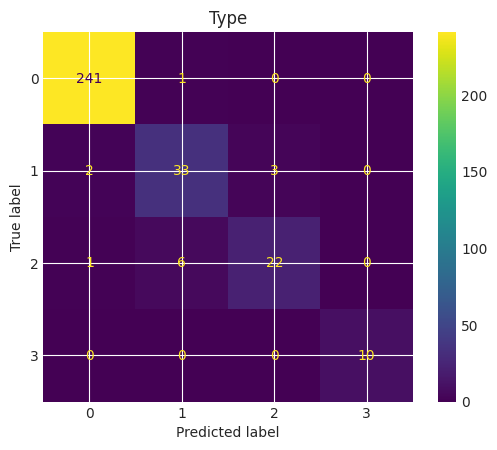

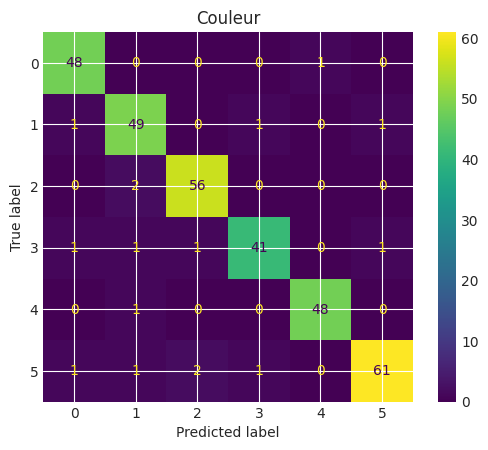

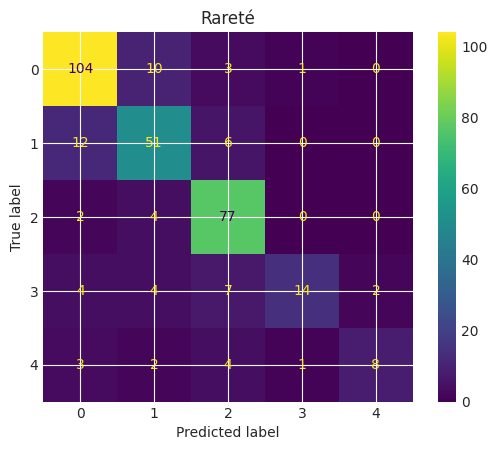

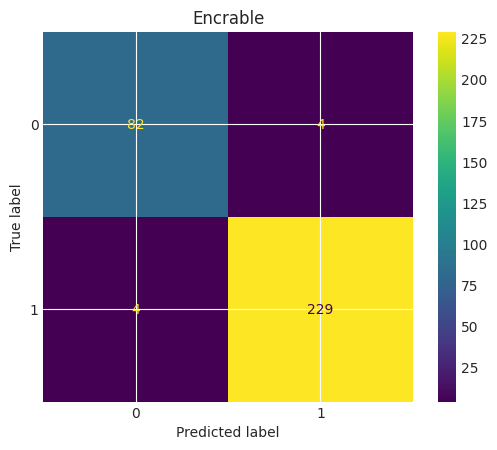

In [13]:


y_true = {
    "type": [],
    "couleur": [],
    "rarete": [],
    "encrable": []
}

y_pred = {
    "type": [],
    "couleur": [],
    "rarete": [],
    "encrable": []
}

for images, labels in val_ds:
    preds = model_frozen.predict(images, verbose=0)

    # preds = liste dans l'ordre des outputs
    pred_type, pred_couleur, pred_rarete, pred_encrable = preds

    y_true["type"].extend(labels["type"].numpy())
    y_true["couleur"].extend(labels["couleur"].numpy())
    y_true["rarete"].extend(labels["rarete"].numpy())
    y_true["encrable"].extend(labels["encrable"].numpy())

    y_pred["type"].extend(np.argmax(pred_type, axis=1))
    y_pred["couleur"].extend(np.argmax(pred_couleur, axis=1))
    y_pred["rarete"].extend(np.argmax(pred_rarete, axis=1))
    y_pred["encrable"].extend((pred_encrable > 0.5).astype(int).flatten())

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(title)
    plt.show()

plot_confusion(y_true["type"], y_pred["type"], "Type")
plot_confusion(y_true["couleur"], y_pred["couleur"], "Couleur")
plot_confusion(y_true["rarete"], y_pred["rarete"], "Rareté")
plot_confusion(y_true["encrable"], y_pred["encrable"], "Encrable")

dict_keys(['couleur_accuracy', 'couleur_loss', 'couleur_top2_couleur_accuracy', 'encrable_accuracy', 'encrable_loss', 'encrable_precision', 'encrable_recall', 'loss', 'rarete_accuracy', 'rarete_loss', 'rarete_top2_rarete_accuracy', 'type_accuracy', 'type_loss', 'type_top2_type_accuracy', 'val_couleur_accuracy', 'val_couleur_loss', 'val_couleur_top2_couleur_accuracy', 'val_encrable_accuracy', 'val_encrable_loss', 'val_encrable_precision', 'val_encrable_recall', 'val_loss', 'val_rarete_accuracy', 'val_rarete_loss', 'val_rarete_top2_rarete_accuracy', 'val_type_accuracy', 'val_type_loss', 'val_type_top2_type_accuracy', 'learning_rate'])


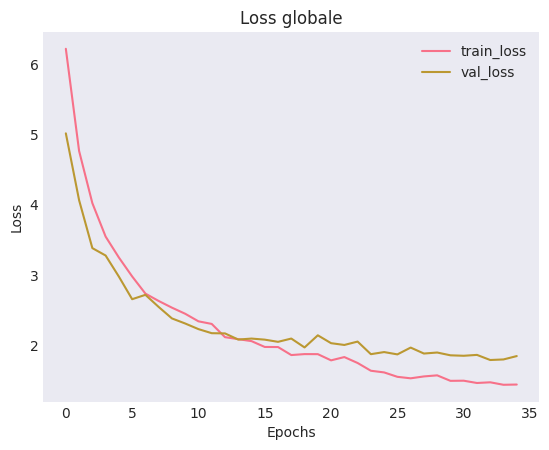

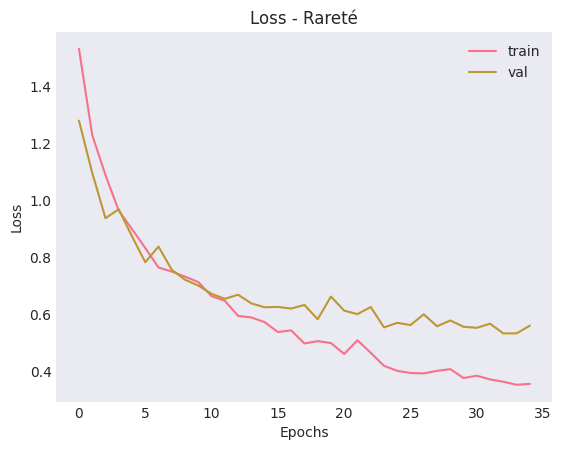

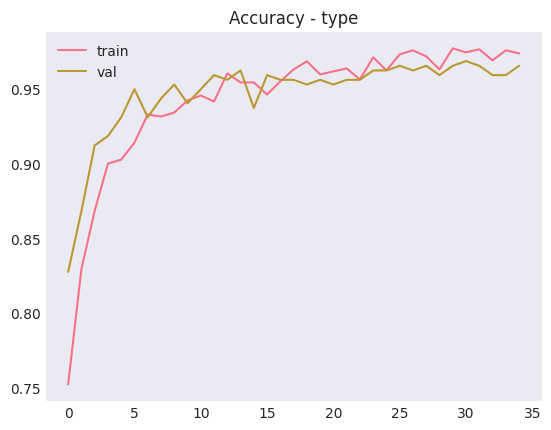

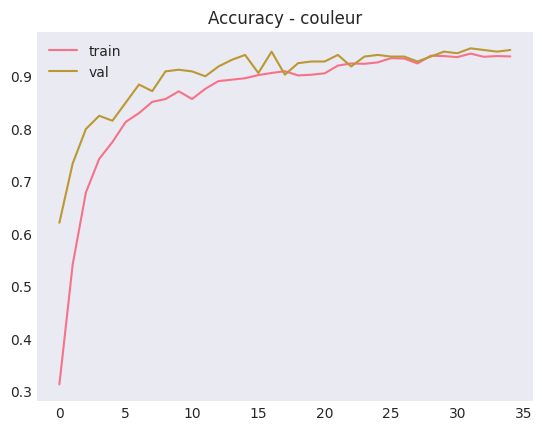

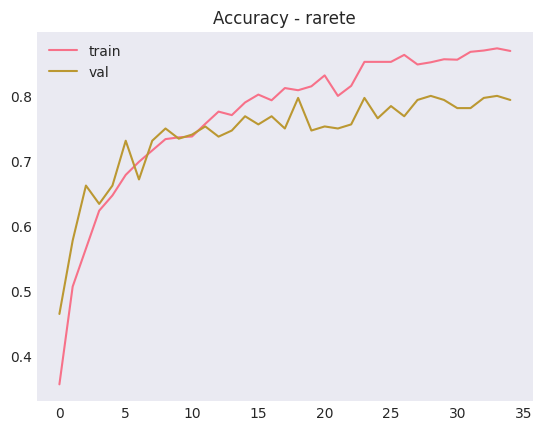

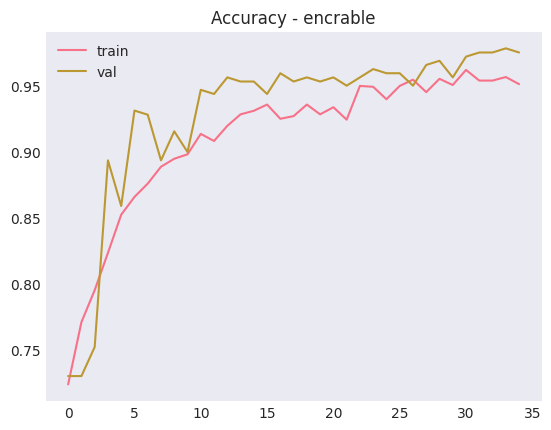

In [23]:
print(history_frozen.history.keys())



plt.figure()
plt.plot(history_frozen.history['loss'], label='train_loss')
plt.plot(history_frozen.history['val_loss'], label='val_loss')
plt.title('Loss globale')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(history_frozen.history['rarete_loss'], label='train')
plt.plot(history_frozen.history['val_rarete_loss'], label='val')
plt.title("Loss - Rareté")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

metrics = ["type", "couleur", "rarete", "encrable"]

for m in metrics:
    plt.figure()
    plt.plot(history_frozen.history[f"{m}_accuracy"], label="train")
    plt.plot(history_frozen.history[f"val_{m}_accuracy"], label="val")
    plt.title(f"Accuracy - {m}")
    plt.legend()
    plt.grid()
    plt.show()

## Prépartion modèle en fine-tuning

In [43]:
print("🔥 Préparation du Fine-Tuning (Approche Directe et Simple)...\n")

# APPROCHE LA PLUS SIMPLE : Modifier le modèle frozen en place
print("💡 Stratégie : Dégeler le base_model et continuer l'entraînement\n")

# Évaluation AVANT fine-tuning
print("📈 Performance AVANT fine-tuning :")
results_before = model_frozen.evaluate(val_ds, verbose=0)
print(f"  - Accuracy : {results_before[1]*100:.2f}%")
print(f"  - Loss     : {results_before[0]:.4f}\n")

# Dégeler le base_model
base_model.trainable = True

# Geler seulement les 100 premières couches
fine_tune_at = 100

for i, layer in enumerate(base_model.layers):
    if i < fine_tune_at:
        layer.trainable = False
    else:
        layer.trainable = True

print(f"📊 Configuration du dégel :")
print(f"  - Couches frozen  : {fine_tune_at}")
print(f"  - Couches unfrozen: {len(base_model.layers) - fine_tune_at}")

# Compter les paramètres
trainable_count = sum([tf.size(w).numpy() for w in model_frozen.trainable_weights])
non_trainable_count = sum([tf.size(w).numpy() for w in model_frozen.non_trainable_weights])
total = trainable_count + non_trainable_count

print(f"  - Paramètres entraînables : {trainable_count:,} ({trainable_count/total*100:.1f}%)")
print(f"  - Paramètres frozen       : {non_trainable_count:,}\n")

# Recompiler avec un LR très faible
FINE_TUNE_LR = 1e-5  # LR très faible

model_frozen.compile(
    optimizer=optimizers.Adam(learning_rate=FINE_TUNE_LR),  # LR standard
    loss={
        'type': 'sparse_categorical_crossentropy',
        'couleur': 'sparse_categorical_crossentropy',
        'rarete': 'sparse_categorical_crossentropy',
        'encrable': 'binary_crossentropy'
    },
    loss_weights={
        "type": 1,
        "couleur": 1,
        "rarete": 1,   # boost rareté
        "encrable": 1
    },
    metrics={
        'type':['accuracy', keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top2_type_accuracy')],
        'couleur': ['accuracy', keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top2_couleur_accuracy')],
        'rarete': ['accuracy', keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top2_rarete_accuracy')],
        'encrable': ['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
    }
)

# Le modèle fine-tuned est le modèle frozen modifié
model_finetuned = model_frozen

print(f"✅ Modèle recompilé avec LR = {FINE_TUNE_LR}")
print("\n💡 Le modèle va continuer depuis les poids déjà appris.")

# Vérification immédiate
print("\n🔍 Vérification immédiate :")
results_after_compile = model_finetuned.evaluate(val_ds, verbose=0)
print(f"  - Accuracy : {results_after_compile[1]*100:.2f}%")
print(f"  - Loss     : {results_after_compile[0]:.4f}")

if abs(results_after_compile[1] - results_before[1]) < 0.01:
    print(f"\n  ✅ Parfait ! Les poids sont préservés ({results_after_compile[1]*100:.1f}%)")
else:
    print(f"\n  ⚠️  Les performances ont changé après recompilation")

🔥 Préparation du Fine-Tuning (Approche Directe et Simple)...

💡 Stratégie : Dégeler le base_model et continuer l'entraînement

📈 Performance AVANT fine-tuning :
  - Accuracy : 159.05%
  - Loss     : 8.1016

📊 Configuration du dégel :
  - Couches frozen  : 100
  - Couches unfrozen: 55
  - Paramètres entraînables : 2,193,488 (84.7%)
  - Paramètres frozen       : 396,544

✅ Modèle recompilé avec LR = 1e-05

💡 Le modèle va continuer depuis les poids déjà appris.

🔍 Vérification immédiate :
  - Accuracy : 159.05%
  - Loss     : 6.7094

  ✅ Parfait ! Les poids sont préservés (159.0%)


In [6]:
print(model_frozen.metrics_names)
print(results_before)

['loss', 'compile_metrics', 'type_loss', 'couleur_loss', 'rarete_loss', 'encrable_loss']
[7.922555923461914, 1.9846296310424805, 1.9727802276611328, 1.6009066104888916, 0.6706892251968384, 0.19122256338596344, 0.35736677050590515, 0.5862069129943848, 0.7487684488296509, 0.6523604989051819, 0.2507837116718292, 0.4670846462249756, 0.07523510605096817, 0.29467085003852844]


## Entrainement du modèle fine-tuning

In [44]:
print("🚀 Entraînement du modèle finetuned...\n")

# Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,  # Patience raisonnable
    restore_best_weights=True,
    mode='min',
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-8,
    verbose=1
)

checkpoint = callbacks.ModelCheckpoint(
    'best_model_finetuned.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=0
)

EPOCHS_FINETUNED = 50

print(f"Configuration :")
print(f"  - Epochs max : {EPOCHS_FINETUNED}")
print(f"  - Patience   : 20 epochs")
print(f"  - LR initial : {FINE_TUNE_LR}")
print(f"  - LR min     : 1e-8\n")

history_finetuned = model_finetuned.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINETUNED,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

print("\n✅ Entraînement finetuned terminé !")
print(f"   Epochs effectués : {len(history_finetuned.history['loss'])}")

best_val_type_acc = max(history_finetuned.history['val_type_accuracy'])
best_type_epoch = history_finetuned.history['val_type_accuracy'].index(best_val_type_acc) + 1
print(f" Meilleurs val_type_acc : {best_val_type_acc*100:.2f}% (epoch {best_type_epoch})")
best_val_couleur_acc = max(history_finetuned.history['val_couleur_accuracy'])
best_couleur_epoch = history_finetuned.history['val_couleur_accuracy'].index(best_val_couleur_acc) + 1
print(f" Meilleurs val_couleur_acc : {best_val_couleur_acc*100:.2f}% (epoch {best_couleur_epoch})")
best_val_rarete_acc = max(history_finetuned.history['val_rarete_accuracy'])
best_rarete_epoch = history_finetuned.history['val_rarete_accuracy'].index(best_val_rarete_acc) + 1
print(f" Meilleurs val_rarete_acc : {best_val_rarete_acc*100:.2f}% (epoch {best_rarete_epoch})")
best_val_encrable_acc = max(history_finetuned.history['val_encrable_accuracy'])
best_encrable_epoch = history_finetuned.history['val_encrable_accuracy'].index(best_val_encrable_acc) + 1
print(f" Meilleurs val_encrable_acc : {best_val_encrable_acc*100:.2f}% (epoch {best_encrable_epoch})")




🚀 Entraînement du modèle finetuned...

Configuration :
  - Epochs max : 50
  - Patience   : 20 epochs
  - LR initial : 1e-05
  - LR min     : 1e-8

Epoch 1/50


47/47 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - couleur_accuracy: 0.2242 - couleur_loss: 1.9565 - couleur_top2_couleur_accuracy: 0.4040 - encrable_accuracy: 0.7027 - encrable_loss: 0.6092 - encrable_precision_6: 0.7684 - encrable_recall_6: 0.8766 - loss: 5.8568 - rarete_accuracy: 0.2866 - rarete_loss: 1.6785 - rarete_top2_rarete_accuracy: 0.5490 - type_accuracy: 0.5054 - type_loss: 1.1786 - type_top2_type_accuracy: 0.7356 - val_couleur_accuracy: 0.1567 - val_couleur_loss: 2.2743 - val_couleur_top2_couleur_accuracy: 0.3229 - val_encrable_accuracy: 0.7241 - val_encrable_loss: 0.6034 - val_encrable_precision_6: 0.7331 - val_encrable_recall_6: 0.9785 - val_loss: 6.1891 - val_rarete_accuracy: 0.2539 - val_rarete_loss: 1.7027 - val_rarete_top2_rarete_accuracy: 0.5298 - val_type_accuracy: 0.5204 - val_type_loss: 1.1824 - val_type_top2_type_accuracy: 0.7743 - learning_rate: 1.0000e-05
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - couleur_accuracy: 0.2846 - couleur_loss: 1.7501 - couleur_top2_co

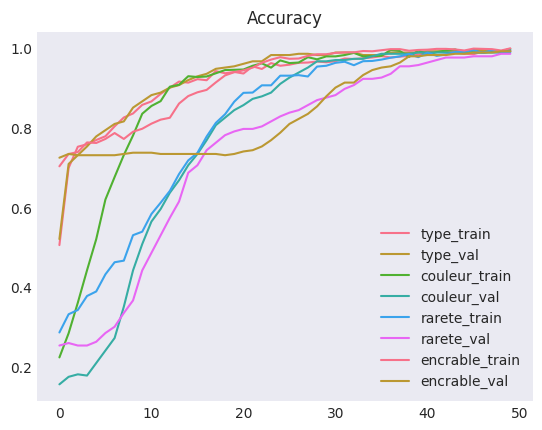

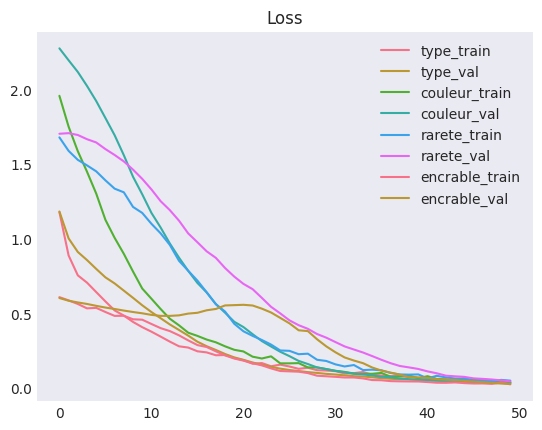

In [46]:
metrics = ["type", "couleur", "rarete", "encrable"]


plt.figure()
for m in metrics:
    plt.plot(history_finetuned.history[f"{m}_accuracy"], label=f"{m}_train")
    plt.plot(history_finetuned.history[f"val_{m}_accuracy"], label=f"{m}_val")
plt.title("Accuracy")
plt.legend()
plt.grid()
plt.show()

plt.figure()
for m in metrics:
    plt.plot(history_finetuned.history[f"{m}_loss"], label=f"{m}_train")
    plt.plot(history_finetuned.history[f"val_{m}_loss"], label=f"{m}_val")
plt.title("Loss")
plt.legend()
plt.grid()
plt.show()

In [2]:
import json
import os
from datetime import datetime

def save_history(history, config, folder="experiments"):
    os.makedirs(folder, exist_ok=True)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # fichiers
    history_path = os.path.join(folder, f"history_{timestamp}.json")
    config_path = os.path.join(folder, f"config_{timestamp}.json")

    # sauvegarde historique
    with open(history_path, "w") as f:
        json.dump(history.history, f)

    # sauvegarde config (paramètres du run)
    with open(config_path, "w") as f:
        json.dump(config, f)

    print(f"✅ Historique sauvegardé : {history_path}")
    print(f"⚙️ Config sauvegardée : {config_path}")


def compare_histories(histories, labels, metric):
    plt.figure()

    for hist, label in zip(histories, labels):
        plt.plot(hist[metric], label=f"{label} - train")
        plt.plot(hist[f"val_{metric}"], linestyle="--", label=f"{label} - val")

    plt.title(metric)
    plt.xlabel("Epochs")
    plt.ylabel(metric)
    plt.legend()
    plt.grid()
    plt.show()


In [45]:
config = {
    "loss_weights": {"type":1, "couleur":1, "rarete":1, "encrable":1},
    "epochs": EPOCHS_FINETUNED,
    "batch_size": BATCH_SIZE,
    "LR" : FINE_TUNE_LR,
    "frozen_layers" : fine_tune_at,
    "model": "MobileNetV2_finetuned"
}

save_history(history_finetuned, config)

✅ Historique sauvegardé : experiments/history_20260413_143912.json
⚙️ Config sauvegardée : experiments/config_20260413_143912.json


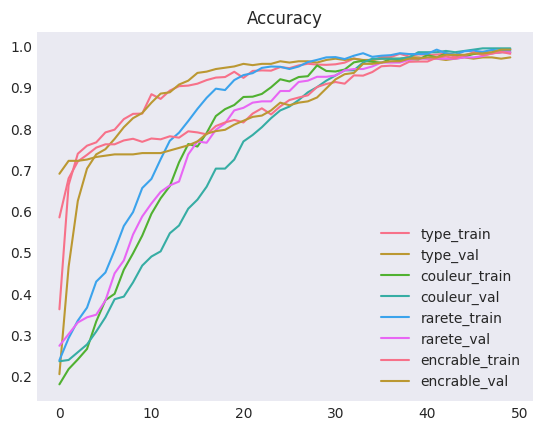

Les poids utilisés : {'type': 1.1, 'couleur': 0.8, 'rarete': 1.2, 'encrable': 0.9} pour un nombre de couches gelées : 120


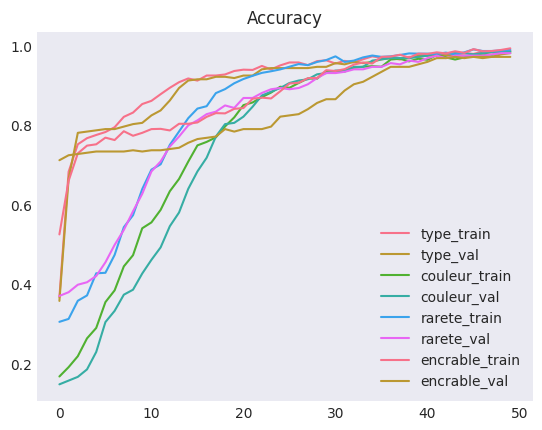

Les poids utilisés : {'type': 1, 'couleur': 0.8, 'rarete': 1.2, 'encrable': 0.9} pour un nombre de couches gelées : 120


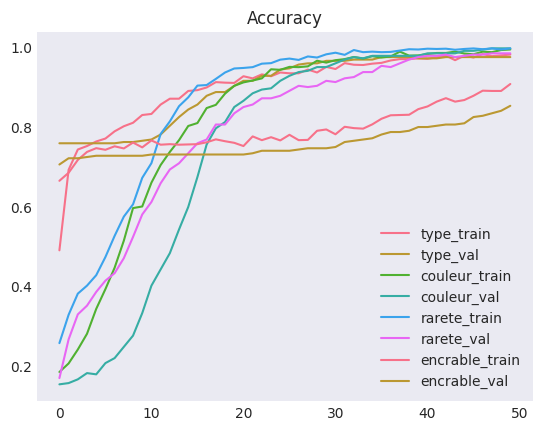

Les poids utilisés : {'type': 1, 'couleur': 1, 'rarete': 2, 'encrable': 0.5} pour un nombre de couches gelées : 100


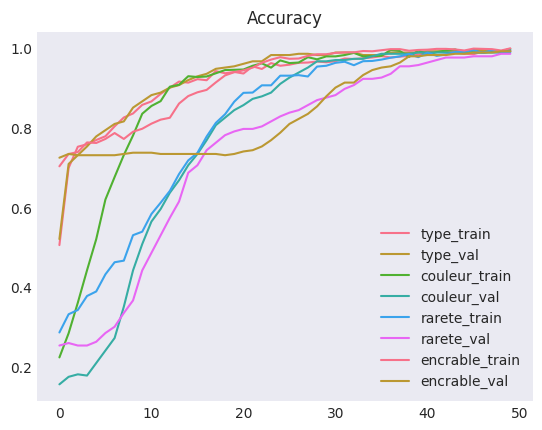

Les poids utilisés : {'type': 1, 'couleur': 1, 'rarete': 1, 'encrable': 1} pour un nombre de couches gelées : 100


In [5]:
def load_history(filepath):
    with open(filepath,"r") as f:
        return json.load(f)

def load_config(filepath):
    with open(filepath,"r") as f:
        return json.load(f)

def plot_history (h,m):
    plt.figure()
    for m in metrics:
        plt.plot(h[f"{m}_accuracy"], label=f"{m}_train")
        plt.plot(h[f"val_{m}_accuracy"], label=f"{m}_val")
    plt.title("Accuracy")
    plt.legend()
    plt.grid()
    plt.show()


metrics = ["type", "couleur", "rarete", "encrable"]
h1 = load_history("experiments/history_20260413_114010.json")
plot_history(h1, metrics)
c1 = load_config("experiments/config_20260413_114010.json")
print(f"Les poids utilisés : {c1["loss_weights"]} pour un nombre de couches gelées : {c1["frozen_layers"]}" )
h2 = load_history("experiments/history_20260413_123758.json")
plot_history(h2, metrics)
c2 = load_config("experiments/config_20260413_123758.json")
print(f"Les poids utilisés : {c2["loss_weights"]} pour un nombre de couches gelées : {c2["frozen_layers"]}" )
h4 = load_history("experiments/history_20260412_160430.json")
plot_history(h4, metrics)
c4 = load_config("experiments/config_20260412_160430.json")
print(f"Les poids utilisés : {c4["loss_weights"]} pour un nombre de couches gelées : {c4["frozen_layers"]}" )
h5 = load_history("experiments/history_20260413_143912.json")
plot_history(h5, metrics)
c5 = load_config("experiments/config_20260413_143912.json")
print(f"Les poids utilisés : {c5["loss_weights"]} pour un nombre de couches gelées : {c5["frozen_layers"]}" )


## Calcul de la meilleur epoch

In [36]:
def find_best_epoch_weighted(history, weights=None):
    metrics = [
        "val_type_accuracy",
        "val_couleur_accuracy",
        "val_rarete_accuracy",
        "val_encrable_accuracy"
    ]

    if weights is None:
        weights = [1, 1, 1, 1]

    n_epochs = len(history[metrics[0]])
    scores = []

    for i in range(n_epochs):
        values = np.array([history[m][i] for m in metrics])

        # score = moyenne pondérée - pénalité déséquilibre
        mean = np.average(values, weights=weights)
        std = np.std(values)

        score = mean - std  # 🔥 équilibre + performance

        scores.append(score)

    best_epoch = np.argmax(scores) + 1

    print(f"✅ Meilleure epoch : {best_epoch}")
    print(f"Score : {scores[best_epoch-1]:.4f}")

    return best_epoch

find_best_epoch_weighted(h4)

✅ Meilleure epoch : 50
Score : 0.8942


50

In [49]:
def top_epochs(history, top_k=5):
    metrics = [
        "val_type_accuracy",
        "val_couleur_accuracy",
        "val_rarete_accuracy",
        "val_encrable_accuracy"
    ]

    results = []

    for i in range(len(history[metrics[0]])):
        values = np.array([history[m][i] for m in metrics])
        score = np.mean(values) - np.std(values)

        results.append((i+1, score))

    results.sort(key=lambda x: x[1], reverse=True)

    for e, s in results[:top_k]:
        print(f"Epoch {e} → score {s:.4f}")

top_epochs(h5, 20)

Epoch 50 → score 0.9864
Epoch 49 → score 0.9852
Epoch 48 → score 0.9812
Epoch 46 → score 0.9811
Epoch 47 → score 0.9811
Epoch 45 → score 0.9785
Epoch 44 → score 0.9783
Epoch 43 → score 0.9775
Epoch 42 → score 0.9736
Epoch 41 → score 0.9695
Epoch 40 → score 0.9645
Epoch 39 → score 0.9622
Epoch 38 → score 0.9573
Epoch 37 → score 0.9425
Epoch 36 → score 0.9356
Epoch 35 → score 0.9313
Epoch 34 → score 0.9259
Epoch 33 → score 0.9086
Epoch 32 → score 0.9034
Epoch 31 → score 0.8893
